In [2]:
#Install packages

!pip install pretty_midi tensorflow pandas numpy matplotlib

  Using cached pretty_midi-0.2.11-py3-none-any.whl
  Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached mido-1.3.3-py3-none-any.whl.metadata (6.4 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.78.0-cp312-cp312-macosx_11_0_universal2.whl.metadata (3.8 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (34 kB)
Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl (223.5 MB)
U

In [1]:
#Imports

import os
import numpy as np
import pandas as pd
import pretty_midi
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

: 

In [41]:
DATASET_ROOT = "maestro"   # if notebook is in same parent folder
print(DATASET_ROOT)

maestro


In [42]:
#Collect all MIDI file paths

midi_files = []

for root, _, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.lower().endswith(".midi") or file.lower().endswith(".mid"):
            midi_files.append(os.path.join(root, file))

midi_files = sorted(midi_files)

print("Total MIDI files found:", len(midi_files))
print("First 5 files:")
for f in midi_files[:5]:
    print(f)

Total MIDI files found: 1276
First 5 files:
maestro/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
maestro/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi
maestro/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi
maestro/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi
maestro/2004/MIDI-Unprocessed_SMF_05_R1_2004_01_ORIG_MID--AUDIO_05_R1_2004_02_Track02_wav.midi


In [43]:
midi_files = midi_files[:5]
print("Using", len(midi_files), "files for this test run")
for f in midi_files:
    print(f)

Using 5 files for this test run
maestro/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
maestro/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi
maestro/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi
maestro/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi
maestro/2004/MIDI-Unprocessed_SMF_05_R1_2004_01_ORIG_MID--AUDIO_05_R1_2004_02_Track02_wav.midi


In [44]:
#MIDI to notes function

def midi_to_notes(midi_file: str) -> pd.DataFrame:
    pm = pretty_midi.PrettyMIDI(midi_file)

    if len(pm.instruments) == 0:
        return pd.DataFrame(columns=["pitch", "step", "duration"])

    instrument = pm.instruments[0]

    if len(instrument.notes) == 0:
        return pd.DataFrame(columns=["pitch", "step", "duration"])

    notes = []
    sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
    prev_start = sorted_notes[0].start

    for note in sorted_notes:
        start = note.start
        end = note.end

        notes.append({
            "pitch": note.pitch,
            "step": start - prev_start,
            "duration": end - start,
        })

        prev_start = start

    return pd.DataFrame(notes)

In [45]:
#Test one file first

test_notes = midi_to_notes(midi_files[0])
print(test_notes.head())
print("Number of notes:", len(test_notes))

   pitch      step  duration
0     71  0.000000  0.096875
1     55  0.186458  0.217708
2     71  0.009375  0.505208
3     59  0.175000  0.167708
4     62  0.169792  0.119792
Number of notes: 7894


In [46]:
#Sequence function

SEQ_LENGTH = 32

def create_sequences(notes_array, seq_length=32):
    X = []
    y = []

    for i in range(len(notes_array) - seq_length):
        X.append(notes_array[i:i + seq_length])
        y.append(notes_array[i + seq_length])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [47]:
#Compute global normalization stats

global_step_max = 0.0
global_duration_max = 0.0

processed_for_stats = 0
skipped_for_stats = 0

for midi_file in midi_files:
    try:
        notes_df = midi_to_notes(midi_file)

        if notes_df.empty:
            skipped_for_stats += 1
            continue

        global_step_max = max(global_step_max, notes_df["step"].max())
        global_duration_max = max(global_duration_max, notes_df["duration"].max())
        processed_for_stats += 1

    except Exception as e:
        skipped_for_stats += 1
        print(f"Skipping stats for {midi_file}: {e}")

print("Processed for stats:", processed_for_stats)
print("Skipped for stats:", skipped_for_stats)
print("global_step_max =", global_step_max)
print("global_duration_max =", global_duration_max)

Processed for stats: 5
Skipped for stats: 0
global_step_max = 14.455208333333303
global_duration_max = 10.248958333333348


In [48]:
#Build the full training dataset

all_sequences = []
all_targets = []

processed_files = 0
skipped_files = 0

for i, midi_file in enumerate(midi_files):
    try:
        notes_df = midi_to_notes(midi_file)

        if notes_df.empty or len(notes_df) <= SEQ_LENGTH:
            skipped_files += 1
            continue

        notes_array = notes_df[["pitch", "step", "duration"]].values.astype(np.float32)

        # normalize
        notes_array[:, 0] /= 127.0
        notes_array[:, 1] /= global_step_max if global_step_max > 0 else 1.0
        notes_array[:, 2] /= global_duration_max if global_duration_max > 0 else 1.0

        X_file, y_file = create_sequences(notes_array, SEQ_LENGTH)

        if len(X_file) == 0:
            skipped_files += 1
            continue

        all_sequences.append(X_file)
        all_targets.append(y_file)
        processed_files += 1

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(midi_files)} files...")

    except Exception as e:
        skipped_files += 1
        print(f"Skipping {midi_file}: {e}")

X = np.concatenate(all_sequences, axis=0)
y = np.concatenate(all_targets, axis=0)

print("Processed files:", processed_files)
print("Skipped files:", skipped_files)
print("X shape:", X.shape)
print("y shape:", y.shape)

Processed files: 5
Skipped files: 0
X shape: (37081, 32, 3)
y shape: (37081, 3)


In [49]:
# Optional train/validation split

print("Total samples:", len(X))

Total samples: 37081


In [50]:
#Positional embedding layer

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.sequence_length = sequence_length
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model
        )

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        pos_embeddings = self.position_embeddings(positions)
        return inputs + pos_embeddings

In [51]:
# Transformer block

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [52]:
#Build the model

def build_transformer_model(seq_length=32, input_dim=3, d_model=64, num_heads=4, ff_dim=128, dropout=0.1):
    inputs = keras.Input(shape=(seq_length, input_dim))

    x = layers.Dense(d_model)(inputs)
    x = PositionalEmbedding(seq_length, d_model)(x)

    x = TransformerBlock(d_model, num_heads, ff_dim, dropout)(x)
    x = TransformerBlock(d_model, num_heads, ff_dim, dropout)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(3)(x)   # predict [pitch, step, duration]

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [1]:
#Create and compile the model

model = build_transformer_model(
    seq_length=SEQ_LENGTH,
    input_dim=3,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.1
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model.summary()

NameError: name 'build_transformer_model' is not defined

In [54]:
#Train the model

history = model.fit(
    X, y,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=2
)

Epoch 1/20
464/464 - 41s - 88ms/step - loss: 0.0168 - mae: 0.0716 - val_loss: 0.0043 - val_mae: 0.0379
Epoch 2/20
464/464 - 38s - 81ms/step - loss: 0.0048 - mae: 0.0426 - val_loss: 0.0046 - val_mae: 0.0438
Epoch 3/20
464/464 - 41s - 89ms/step - loss: 0.0039 - mae: 0.0367 - val_loss: 0.0046 - val_mae: 0.0390
Epoch 4/20
464/464 - 39s - 83ms/step - loss: 0.0034 - mae: 0.0331 - val_loss: 0.0040 - val_mae: 0.0363
Epoch 5/20
464/464 - 37s - 79ms/step - loss: 0.0032 - mae: 0.0317 - val_loss: 0.0040 - val_mae: 0.0365
Epoch 6/20
464/464 - 36s - 77ms/step - loss: 0.0032 - mae: 0.0316 - val_loss: 0.0040 - val_mae: 0.0359
Epoch 7/20
464/464 - 35s - 75ms/step - loss: 0.0032 - mae: 0.0318 - val_loss: 0.0041 - val_mae: 0.0376
Epoch 8/20
464/464 - 37s - 79ms/step - loss: 0.0031 - mae: 0.0315 - val_loss: 0.0040 - val_mae: 0.0360
Epoch 9/20
464/464 - 37s - 80ms/step - loss: 0.0031 - mae: 0.0311 - val_loss: 0.0040 - val_mae: 0.0352
Epoch 10/20
464/464 - 35s - 75ms/step - loss: 0.0031 - mae: 0.0310 - val_

In [6]:
#Save the model

model.save("maestro_transformer_model.keras")
print("Model saved.")

NameError: name 'model' is not defined

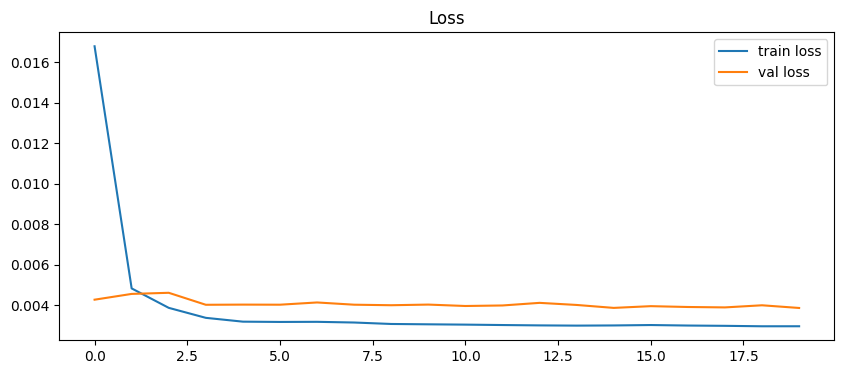

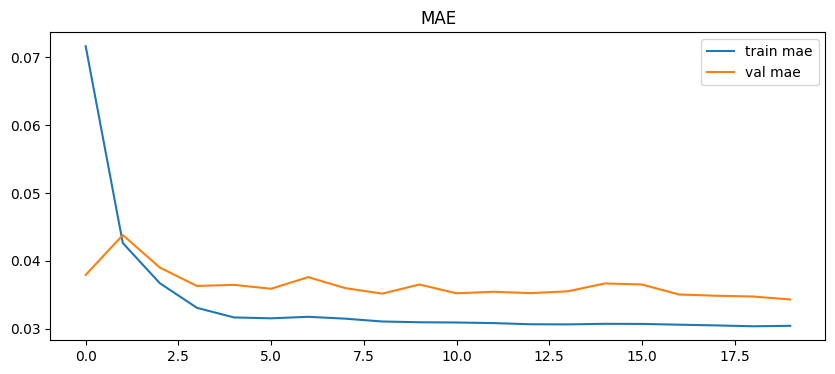

In [56]:
#Plot training history

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["mae"], label="train mae")
plt.plot(history.history["val_mae"], label="val mae")
plt.legend()
plt.title("MAE")
plt.show()

In [57]:
#Predict one next note

sample_input = X[0:1]
pred = model.predict(sample_input)

print("Predicted normalized note:", pred)
print("True normalized note:", y[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
Predicted normalized note: [[0.5522806  0.00590395 0.01657102]]
True normalized note: [[0.62204725 0.01196224 0.01961581]]


In [58]:
#Convert prediction back to real units

pred_pitch = pred[0, 0] * 127.0
pred_step = pred[0, 1] * global_step_max
pred_duration = pred[0, 2] * global_duration_max

print("Predicted pitch:", pred_pitch)
print("Predicted step:", pred_step)
print("Predicted duration:", pred_duration)

Predicted pitch: 70.13963
Predicted step: 0.085342880526635
Predicted duration: 0.1698356816816767


In [59]:
#generate multiple notes

def generate_notes(model, seed_sequence, num_predictions=50):
    generated_notes = []
    current_sequence = seed_sequence.copy()

    for _ in range(num_predictions):
        pred = model.predict(current_sequence[np.newaxis, :, :], verbose=0)[0]

        pred_pitch = pred[0] * 127.0
        pred_step = pred[1] * global_step_max
        pred_duration = pred[2] * global_duration_max

        # clamp to safer musical ranges
        pred_pitch = int(np.clip(round(pred_pitch), 36, 96))
        pred_step = float(np.clip(pred_step, 0.05, 0.5))
        pred_duration = float(np.clip(pred_duration, 0.1, 0.8))

        generated_notes.append({
            "pitch": pred_pitch,
            "step": pred_step,
            "duration": pred_duration
        })

        next_note_normalized = np.array([
            pred_pitch / 127.0,
            pred_step / global_step_max if global_step_max > 0 else 0.0,
            pred_duration / global_duration_max if global_duration_max > 0 else 0.0
        ], dtype=np.float32)

        current_sequence = np.vstack([current_sequence[1:], next_note_normalized])

    return generated_notes

In [60]:
#choose a seed and generate notes

seed_sequence = X[0]
generated_notes = generate_notes(model, seed_sequence, num_predictions=100)

print("Generated", len(generated_notes), "notes")
print(generated_notes[:10])

Generated 100 notes
[{'pitch': 70, 'step': 0.085342880526635, 'duration': 0.1698356816816767}, {'pitch': 68, 'step': 0.11693155101578037, 'duration': 0.24056526722852176}, {'pitch': 65, 'step': 0.052355147249909244, 'duration': 0.1333069229091054}, {'pitch': 66, 'step': 0.06757442334007147, 'duration': 0.15456972887817172}, {'pitch': 64, 'step': 0.08438992670271528, 'duration': 0.19859792829568837}, {'pitch': 62, 'step': 0.12612100054393496, 'duration': 0.2858237137241914}, {'pitch': 67, 'step': 0.06342126059316784, 'duration': 0.14069615598806823}, {'pitch': 62, 'step': 0.11483563418150855, 'duration': 0.26320004571656114}, {'pitch': 64, 'step': 0.053560862160520514, 'duration': 0.13957541013951433}, {'pitch': 65, 'step': 0.05140989058854746, 'duration': 0.12715349214850014}]


In [61]:
#save generated notes as MIDI

def save_generated_notes_to_midi(generated_notes, output_file="generated_music.mid"):
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)  # piano

    current_start = 0.0

    for note_data in generated_notes:
        pitch = int(note_data["pitch"])
        step = float(note_data["step"])
        duration = float(note_data["duration"])

        current_start += step
        end = current_start + duration

        note = pretty_midi.Note(
            velocity=100,
            pitch=max(0, min(127, pitch)),
            start=current_start,
            end=end
        )

        instrument.notes.append(note)

    pm.instruments.append(instrument)
    pm.write(output_file)
    print(f"Saved {output_file}")

In [62]:
# 